#1D Laplace problem with the Finite Element Method (FEM)

Let us consider again the differential problem:
$$
  \begin{cases}
    -u''(x) = f(x) = \sin(x), \qquad&\text{for } x \in (0, 2\pi), \\
    u(0) = u(2\pi) = 0, \qquad &
  \end{cases}
$$

Solving a boundary-value problem such as the Laplace equation in FEniCS consists of the following steps:

1.   Identify the computational domain, the PDE, boundary conditions, and source terms;
2.   Reformulate the PDE as a finite element variational problem;
3.   Write a Python program defining the domain, the weak problem, boundary conditions, and source terms, using the corresponding FEniCS abstractions;
4.   Call FEniCS to solve the boundary-value problem and, optionally, extend the program to compute derived quantities 
and visualize the results.



### The weak formulation

The weak formulation of the problem is obtained by multiplying the equation by a test function $v$ and integrating over the interval $(0, 2\pi)$:
\begin{equation*}
  -\int_0^{2\pi} u'' v \, dx = \int_0^{2\pi} f v \, dx.
\end{equation*}
The first term is integrated by parts:
\begin{equation*}
  {\left[ -u'v \right]}^{2\pi}_0 + \int_0^{2\pi} u' v' \, dx = \int_0^{2\pi} f v \, dx.
\end{equation*}
Since the values of $u$ are fixed for $x=0$ and $x=1$ we assume that $v(0) =
v({2\pi}) = 0$, so that the **weak formulation** reads:
\begin{equation*}
  \text{find } u \in H^1_0(0,{2\pi}) \text{ such that }
  \int_0^{2\pi} u' v' \, dx = \int_0^{2\pi} f v \, dx, \qquad
  \forall v \in H^1_0(0,{2\pi}).
\end{equation*}

### The Galerkin approximation

Let $V_h$ is a finite dimensional subspace of $H^1_0(0, 2\pi)$ (conforming approximation). The **Galerkin approximation** of the weak problem above reads
$$
  \text{find } u_h \in V_h \text{ such that }
  \int_0^{2\pi} u_h' v_h' \, dx = \int_0^{2\pi} f v_h \, dx, \qquad
  \forall v_h \in V_h.
$$
Let $\{\phi_i\}_{i=1}^{N}$ be a basis for the discrete space $V_h$, with $N$ denoting the dimension of $V_h$. Then the previous discrete problem can be rewritten in its algebraic form $A\boldsymbol{x} = \boldsymbol{b}$, where
\begin{equation*}
  A_{ij} = \int_0^{2\pi} \phi_i' \phi_j' \, dx, \qquad
  b_i = \int_0^{2\pi} f \phi_i \, dx,
\end{equation*}
and the entries $x_i$ are the coefficient related to $u_h$ by
\begin{equation*}
  u_h = \sum_{i=1}^{N} x_i \phi_i. 
\end{equation*}

### The Finite Element Method 

Generally in the finite element programming the solving algorithm is divided in the following steps:


*   **STEP 1:** mesh generation;
*   **STEP 2:** creation of finite element spaces (distribution of degrees of freedom);
*   **STEP 3:** assembling matrices and vectors (taking into account the problem data);
*   **STEP 4:** solving the algebraic problem;
*   **STEP 5:** save or visualize the output.







Hereafter, we follow exactly the same steps using the tools provided by FEniCS. First, we import in Colab the FEniCS package by executing the following lines.

In [2]:
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *

E: Package 'python-software-properties' has no installation candidate
Get:1 http://security.ubuntu.com/ubuntu bionic-security InRelease [88.7 kB]
Ign:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu bionic InRelease
Get:4 http://ppa.launchpad.net/fenics-packages/fenics/ubuntu bionic InRelease [15.4 kB]
Ign:5 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  InRelease
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  Release [564 B]
Hit:7 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  Release
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  Release.gpg [819 B]
Get:9 http://archive.ubuntu.com/ubuntu bionic-updates InRelease [88.7 kB]
Get:10 http://ppa.launchpad.net/graphics-drivers/ppa/ubuntu bionic InRelease [21.3 kB]
Get:11 http://security.ubuntu.com/ubuntu bionic-sec

In [0]:
from fenics import *
import matplotlib.pyplot as plt
import numpy as np

#### Step 1: Mesh generation

Let's start defining the domain, in this case it is the interval $[0,2\pi]$. The class
```
IntervalMesh
``` of FEniCS is designed for generating such domains. It accepts three arguments: the number of subdivisions along $x$ axis and the boundary points $0$ and $2\pi$.

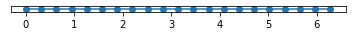

In [24]:
n = 20
mesh = IntervalMesh(n, 0, 2*np.pi)

# The mesh can be visualized using 
plot(mesh)

#### Step 2: Definition of finite element space

Let us now define the finite element space $V_h$. In this case we consider the well known space $\mathbb{P}^k$ spanned by continuous piecewise polynomial functions with degree at most $k$.

In [0]:
k = 1
V = FunctionSpace(mesh, 'CG', k)

The definition of the space is completed by the list of Dirichlet boundary conditions. Each condition is defined by two ingredients: the value of the condition and where the condition is applied. In our case the Dirichlet boundary conditions are homogeneous, namely equal to zero in both boundary points $x=0$ and $x=2\pi$. 

In FEniCS each boundary condition is defined by a function that accepts two arguments: a tuple with the coordinates of a point and a boolean value that is equal to 
```
True
``` if the point is already on the boundary. 

In [0]:
g_boundary = Constant(0.0)

def boundary(x, on_boundary):
    return on_boundary

#print(boundary(0.0, True))

bc = DirichletBC(V, g_boundary, boundary)

#### Step 3: Assembling matrices and vectors

Let’s now define the discrete problem. Once the trial and test functions (u and v) are defined, the problem is simply given by its weak formulation:

In [0]:
u = TrialFunction(V)
v = TestFunction(V)

# the bilinear form in the left-hand side of the formulation is given by
a = dot(grad(u), grad(v)) * dx

# the linear functional in the right-hand side is given by
f = Expression('sin(x[0])', degree=k+1)
L = f * v * dx

#### Step 4: Solve the linear system

In [0]:
u = Function(V)
solve(a == L, u, bc)

#### Step 5: Plot the solution

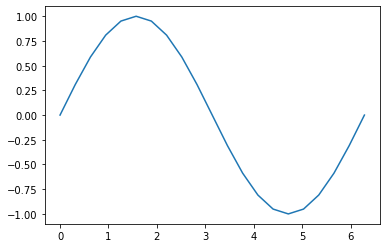

<Figure size 432x288 with 0 Axes>

In [38]:
plot(u)
#plot(mesh)

# the graphics can be shown with the statement
plt.show()

# or it can be saved to a file usign
plt.savefig('laplace.pdf')

There is a second way to postprocess the solution. It can be saved in VTK file and then postprocessed with ParaView:

In [0]:
vtkfile = File('laplace.pvd')
vtkfile << u

#### **Exercise:** compare the solution obtained with FEM together with the one obtained with the finite differences scheme in Lab 1